# 14. Feature Engineering for Operational Machine Learning

Feature engineering is where statistical thinking meets implementation discipline. In operational machine learning, we rarely model the raw business table exactly as it arrives. Instead, we decide how to represent time, scale, ratios, interactions, seasonality, and recent history so that a model sees signals that align with the decision we actually need to support.

That makes feature engineering both powerful and dangerous. Good features can make a simple model far more useful. Bad features can quietly leak future information, encode post-outcome behavior, or create a model that looks strong in validation but cannot survive deployment. Kaufman et al. (2012) define leakage as the introduction of information about the prediction target that should not be legitimately available, and that warning is especially important in business systems where timestamps, rolling aggregates, and operational logs arrive asynchronously. At the same time, automated feature construction from relational and temporal data has become an important practical direction in modern data science workflows (Kanter & Veeramachaneni, 2015; Christ et al., 2018).

In this notebook we study feature engineering through a realistic support-operations example. The prediction target is whether a seller account will breach its service-level agreement on a given day. We will compare three approaches:

1. a **raw lagged baseline** built from simple yesterday-level variables,
2. a **deployable engineered model** with ratios, transforms, rolling summaries, interactions, and cyclical time features,
3. a **leaky model** that cheats by using same-day information that would not exist at decision time.

The point is not to chase tiny benchmark gains. The point is to learn what kinds of features create defensible predictive systems for decisions under uncertainty.

## Learning Objectives

By the end of this notebook, you should be able to:

1. explain feature engineering as the design of a representation map rather than a bag of ad hoc tricks,
2. construct lagged, rolling, transformed, interaction, and cyclical features for panel-style operational data,
3. distinguish **deployable** features from **leaky** features in temporal business settings,
4. evaluate whether engineered features add legitimate predictive value beyond a raw baseline, and
5. interpret which engineered features matter in a simple logistic model.

## 1. Core Mathematical Ideas

Suppose the raw information available for an account at decision time $t$ is a vector $x_t \in \mathbb{R}^p$. A prediction model does not usually operate on $x_t$ directly. Instead, it operates on a **feature map**

$$
\phi(x_t) = z_t \in \mathbb{R}^q,
$$

where $z_t$ may contain transformations, interactions, encodings, and temporal summaries of the raw inputs. A prediction model then estimates

$$
\hat{y}_t = f\bigl(\phi(x_t)\bigr).
$$

This framing is useful because it separates two different design problems:

- **representation design**: what information should the model be allowed to see, and in what form?
- **estimation**: given that representation, what function class should map it to the target?

In operational data, common engineered features include:

1. **transformations of skewed levels** such as
  $$
  z_1 = \log(1 + x),
  $$
  which compress large values and often make relationships more linear;

2. **interaction terms** such as
  $$
  z_2 = x^{(1)} x^{(2)},
  $$
  which allow the effect of one variable to depend on another;

3. **rate features** such as
  $$
  z_3 = \frac{\text{tickets}_{t-1}}{\text{orders}_{t-1}},
  $$
  which normalize activity by exposure or scale;

4. **rolling summaries** such as
  $$
  z_4 = \frac{1}{7}\sum_{s=t-7}^{t-1} x_s,
  $$
  which stabilize noisy day-level measurements;

5. **cyclical encodings** for periodic time variables such as day-of-week:
  $$
  z_5 = \sin\left(\frac{2\pi d_t}{7}\right), \qquad
  z_6 = \cos\left(\frac{2\pi d_t}{7}\right).
  $$

The central deployment constraint is that every engineered feature must be measurable from information available **before** the prediction is made. A concise way to say this is

$$
\phi_t = g(\mathcal{F}_{t^-}),
$$

where $\mathcal{F}_{t^-}$ denotes the information set available just before the decision at time $t$. If a feature uses information recorded after that decision point, then the model is contaminated by leakage (Kaufman et al., 2012). In temporal settings, even innocuous-looking aggregations can leak if they are computed with future observations or with a random split that breaks chronology (Lai et al., 2024).

In [1]:
# Section focus: 1. Core Mathematical Ideas.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import expit

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 200)
pd.options.display.float_format = '{:,.3f}'.format

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

rng = np.random.default_rng(2026)

## 2. Operational Example: Predicting Daily SLA Breaches

We will work with a synthetic but realistic seller-day panel from a marketplace support organization. Each row corresponds to one seller on one day. The operational question is:

> Given everything we legitimately know before today's service window, how likely is this seller to breach its SLA today?

That framing is important. If the prediction is intended for staffing, prioritization, escalation, or risk triage at the start of the day, then the model should not rely on quantities that are only measured after the day unfolds.

### Raw variables in the simulated data

| Variable | Meaning | Why it matters |
|---|---|---|
| `tier`, `region` | Seller segment and geographic context | Baseline scale, staffing, and process friction differ by group |
| `automation_score`, `complexity_score` | Latent seller characteristics | Higher automation usually reduces burden; higher complexity usually increases it |
| `orders_today`, `tickets_today` | Same-day commercial and support load | Exposure and demand are tightly linked to operational stress |
| `promo_spend_today` | Marketing pressure | Promotions can create uneven surges and downstream service burden |
| `knowledge_base_views_today` | Self-service activity | Strong self-service often absorbs support demand |
| `incident_count_today` | Same-day reliability incidents | Incident spikes often propagate into support queues |
| `agent_hours_today` | Staff capacity assigned | Capacity can buffer or amplify queue pressure |
| `backlog_end_today` | End-of-day unresolved pressure | Operational congestion is a direct risk signal |
| `resolution_minutes_today` | Realized service time | A downstream indicator of service stress |
| `sla_breach_today` | Binary target | Whether the account breached its SLA on that day |

Notice that several of these same-day variables would be inappropriate at prediction time if we are scoring the day **before** those same-day events are fully observed. That will become our leakage stress test.

In [2]:
# Section focus: Raw variables in the simulated data.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def simulate_support_operations(n_sellers=220, n_days=180, random_state=2026):
    """Create a simulated support operations data set for the 14. Feature Engineering for Operational Machine Learning case study.
    
    Parameters
    ----------
    n_sellers : object
        Count or size setting for the support operations calculation.
    n_days : object
        Count or size setting for the support operations calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)
    seller_ids = np.arange(n_sellers)

    tiers = np.array(['enterprise', 'growth', 'mid_market', 'long_tail'])
    tier = rng.choice(tiers, size=n_sellers, p=[0.18, 0.27, 0.30, 0.25])

    regions = np.array(['NA', 'EU', 'APAC', 'LATAM'])
    region = rng.choice(regions, size=n_sellers, p=[0.32, 0.24, 0.28, 0.16])

    scale = rng.normal(0, 1, n_sellers)
    automation = rng.normal(0, 1, n_sellers)
    complexity = rng.normal(0, 1, n_sellers)
    seller_effect = rng.normal(0, 0.35, n_sellers)

    tier_scale = {'enterprise': 0.90, 'growth': 0.45, 'mid_market': 0.05, 'long_tail': -0.35}
    staffing_bonus = {'enterprise': 1.5, 'growth': 0.8, 'mid_market': 0.3, 'long_tail': -0.2}
    region_friction = {'NA': -0.08, 'EU': 0.04, 'APAC': 0.12, 'LATAM': 0.18}

    backlog_prev = np.clip(rng.normal(6.5, 1.8, n_sellers), 1, None)
    backlog_prev2 = backlog_prev - rng.normal(0.3, 0.5, n_sellers)
    breach_prev = rng.binomial(1, 0.10, n_sellers)
    incident_prev = rng.poisson(0.5, n_sellers)

    rows = []

    for day in range(n_days):
        dow = day % 7
        weekday_load = [0.15, 0.22, 0.18, 0.10, 0.06, -0.14, -0.20][dow]
        promo_cycle = 0.7 * np.sin(2 * np.pi * day / 28)
        incident_cycle = 0.6 * np.cos(2 * np.pi * day / 18)

        for i in seller_ids:
            log_orders = 2.65 + tier_scale[tier[i]] + 0.32 * scale[i] + 0.08 * promo_cycle + rng.normal(0, 0.14)
            orders = int(np.clip(rng.poisson(np.exp(log_orders)), 8, 220))

            promo_spend = max(
                0.0,
                35 + 12 * (tier[i] in ['enterprise', 'growth']) + 14 * max(scale[i], 0) + 12 * promo_cycle + rng.normal(0, 8)
            )

            kb_views = max(5.0, 25 + 8 * automation[i] + 0.45 * orders + rng.normal(0, 6))

            incidents = rng.poisson(
                max(0.05, 0.25 + 0.35 * max(complexity[i], -0.8) + 0.18 * max(incident_cycle, -0.8) + 0.015 * backlog_prev[i] + 0.12 * incident_prev[i])
            )

            tickets_mean = max(
                0.6,
                1.2 + 0.055 * orders + 1.1 * max(complexity[i], -1.2) - 0.55 * automation[i] + 0.75 * incidents + 0.35 * seller_effect[i] + weekday_load,
            )
            tickets = int(rng.poisson(tickets_mean))

            agent_hours = max(
                1.0,
                3.8 + 0.028 * orders + staffing_bonus[tier[i]] - 0.35 * automation[i] + rng.normal(0, 0.9),
            )

            backlog = max(0.2, 0.60 * backlog_prev[i] + 0.72 * tickets - 0.62 * agent_hours + 0.85 * incidents + rng.normal(0, 0.8))

            backlog_pressure = backlog / max(agent_hours, 1)
            ticket_rate = tickets / max(orders, 1)
            self_service_gap = tickets / max(kb_views, 1)
            backlog_growth = max(backlog_prev[i] - backlog_prev2[i], 0)
            incident_trend = max(incidents - incident_prev[i], 0)

            resolution_minutes = max(
                10.0,
                26 + 9.5 * backlog_pressure + 52 * ticket_rate + 8 * incidents + 12 * region_friction[region[i]] - 5 * automation[i] + 4.5 * backlog_growth + rng.normal(0, 5),
            )

            breach_logit = (
                -3.05
                + 0.42 * np.log1p(backlog)
                + 3.9 * ticket_rate
                + 1.4 * self_service_gap
                + 0.16 * incidents
                + 0.95 * breach_prev[i]
                + 0.36 * backlog_growth
                + 0.26 * incident_trend
                + 0.45 * region_friction[region[i]]
                + 0.10 * (dow in [0, 1, 2])
                - 0.20 * automation[i]
            )
            breach = rng.binomial(1, expit(breach_logit))

            rows.append(
                {
                    'seller_id': i,
                    'date': pd.Timestamp('2024-01-01') + pd.Timedelta(days=day),
                    'tier': tier[i],
                    'region': region[i],
                    'automation_score': automation[i],
                    'complexity_score': complexity[i],
                    'day_of_week': dow,
                    'orders_today': orders,
                    'tickets_today': tickets,
                    'promo_spend_today': promo_spend,
                    'knowledge_base_views_today': kb_views,
                    'incident_count_today': incidents,
                    'agent_hours_today': agent_hours,
                    'backlog_end_today': backlog,
                    'resolution_minutes_today': resolution_minutes,
                    'sla_breach_today': breach,
                }
            )

            backlog_prev2[i] = backlog_prev[i]
            backlog_prev[i] = backlog
            breach_prev[i] = breach
            incident_prev[i] = incidents

    return pd.DataFrame(rows)


ops = simulate_support_operations()

overview = pd.DataFrame(
    [
        {'quantity': 'Rows', 'value': len(ops)},
        {'quantity': 'Unique sellers', 'value': ops['seller_id'].nunique()},
        {'quantity': 'Date range', 'value': f"{ops['date'].min().date()} to {ops['date'].max().date()}"},
        {'quantity': 'Overall breach rate', 'value': round(ops['sla_breach_today'].mean(), 3)},
        {'quantity': 'Median daily tickets', 'value': round(ops['tickets_today'].median(), 1)},
        {'quantity': 'Median end-of-day backlog', 'value': round(ops['backlog_end_today'].median(), 2)},
    ]
)

display(overview)
ops.head()

,quantity,value
0,Rows,39600
1,Unique sellers,220
2,Date range,2024-01-01 to 2024-06-28
3,Overall breach rate,0.230
4,Median daily tickets,2.000
5,Median end-of-day backlog,0.200


,seller_id,date,tier,region,automation_score,complexity_score,day_of_week,orders_today,tickets_today,promo_spend_today,knowledge_base_views_today,incident_count_today,agent_hours_today,backlog_end_today,resolution_minutes_today,sla_breach_today
0,0,2024-01-01,enterprise,EU,0.008,-2.070,0,27,1,47.491,22.633,0,5.334,2.470,34.124,0
1,1,2024-01-01,mid_market,EU,0.199,1.214,0,23,4,66.094,38.252,2,4.328,5.665,67.018,0
2,2,2024-01-01,mid_market,APAC,-0.941,-0.062,0,22,8,47.401,19.281,1,3.782,8.474,83.705,1
3,3,2024-01-01,growth,EU,-0.185,0.200,0,19,4,37.358,28.187,1,6.166,5.260,58.807,1
4,4,2024-01-01,growth,EU,-0.512,-0.106,0,22,4,63.891,30.554,0,6.174,4.410,46.815,0


The simulated data already have several properties that make the example realistic enough for teaching:

- the target is neither too rare nor too common,
- scale differs across seller tiers,
- support demand and incidents create queue pressure,
- queue pressure affects realized service times and breach risk,
- recent operational history matters alongside today's raw level.

That last point is the opening for feature engineering. If two sellers both had 6 tickets yesterday, but one has had a rising backlog and repeated recent breaches while the other has been stable, those sellers should not be represented identically.

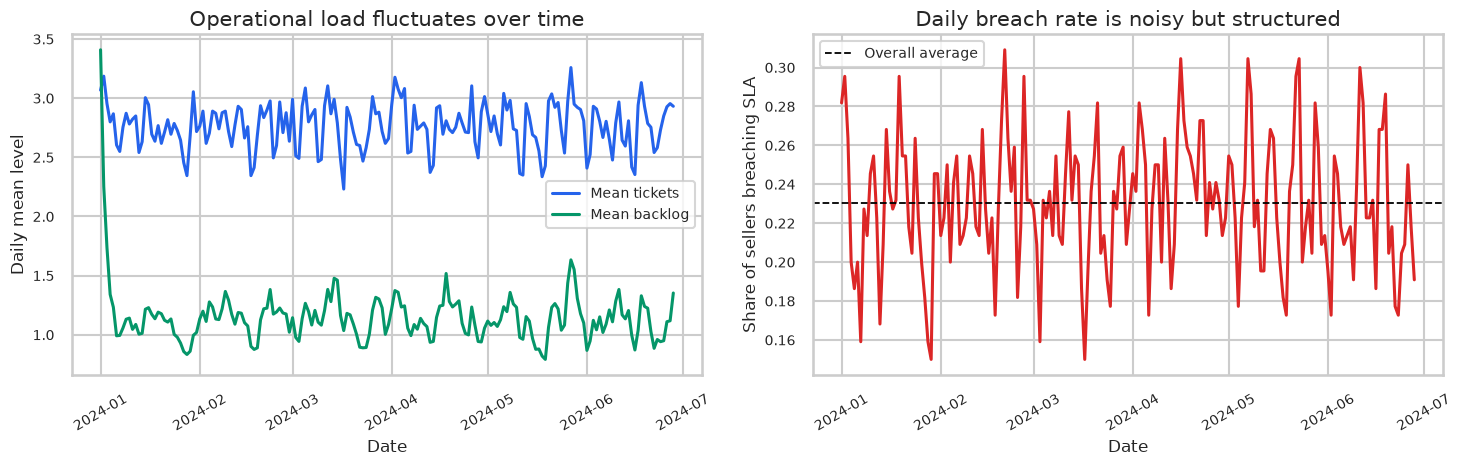

In [3]:
# Section focus: Raw variables in the simulated data.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

daily_ops = (
    ops.groupby('date')
    .agg(
        mean_backlog=('backlog_end_today', 'mean'),
        mean_tickets=('tickets_today', 'mean'),
        breach_rate=('sla_breach_today', 'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=daily_ops, x='date', y='mean_tickets', ax=axes[0], color='#2563eb', linewidth=2.2, label='Mean tickets')
sns.lineplot(data=daily_ops, x='date', y='mean_backlog', ax=axes[0], color='#059669', linewidth=2.2, label='Mean backlog')
axes[0].set_title('Operational load fluctuates over time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Daily mean level')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(frameon=True)

sns.lineplot(data=daily_ops, x='date', y='breach_rate', ax=axes[1], color='#dc2626', linewidth=2.2)
axes[1].axhline(ops['sla_breach_today'].mean(), color='black', linestyle='--', linewidth=1.3, label='Overall average')
axes[1].set_title('Daily breach rate is noisy but structured')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Share of sellers breaching SLA')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

The practical question in Raw variables in the simulated data is simple. What would this result make the analyst do differently?


## 3. Turning Raw Logs into Deployable Features

We now build a feature set that respects chronology. The model is allowed to use information that would be available from prior days, but not information recorded after today's support operations finish.

### Feature families we will create

| Feature family | Examples | Why it helps |
|---|---|---|
| One-day lags | `tickets_today_lag1`, `backlog_end_today_lag1` | Preserve recent state without using same-day outcomes |
| Log transforms | `log_orders_lag1`, `log_backlog_lag1` | Compress skew and reduce leverage of large accounts |
| Ratios and normalizations | `ticket_rate_lag1`, `backlog_per_hour_lag1` | Compare burden relative to demand or capacity |
| Rolling summaries | `tickets_7d_avg`, `backlog_7d_avg`, `breach_14d_rate` | Smooth day noise and recover trajectory |
| Interactions | `promo_pressure_interaction`, `incident_pressure_interaction` | Let one risk factor amplify another |
| Cyclical time encodings | `dow_sin`, `dow_cos` | Represent weekly periodicity without fake Monday-to-Sunday linearity |

The key teaching point is that feature engineering should map onto an explicit business hypothesis. If we create `backlog_per_hour_lag1`, we are asserting that congestion relative to capacity is more informative than raw backlog alone. If we create `breach_14d_rate`, we are asserting that recent service instability carries signal beyond yesterday's snapshot.

In [4]:
# Section focus: Feature families we will create.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def build_feature_matrix(df):
    """Build the feature matrix object used in the 14. Feature Engineering for Operational Machine Learning analysis.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the feature matrix workflow for later analysis.
    """
    df = df.sort_values(['seller_id', 'date']).copy()

    lag_cols = [
        'orders_today',
        'tickets_today',
        'promo_spend_today',
        'knowledge_base_views_today',
        'incident_count_today',
        'agent_hours_today',
        'backlog_end_today',
        'resolution_minutes_today',
        'sla_breach_today',
    ]
    for col in lag_cols:
        df[f'{col}_lag1'] = df.groupby('seller_id')[col].shift(1)

    df['tickets_3d_avg'] = df.groupby('seller_id')['tickets_today'].transform(lambda s: s.shift(1).rolling(3, min_periods=2).mean())
    df['tickets_7d_avg'] = df.groupby('seller_id')['tickets_today'].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
    df['backlog_3d_avg'] = df.groupby('seller_id')['backlog_end_today'].transform(lambda s: s.shift(1).rolling(3, min_periods=2).mean())
    df['backlog_7d_avg'] = df.groupby('seller_id')['backlog_end_today'].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
    df['breach_14d_rate'] = df.groupby('seller_id')['sla_breach_today'].transform(lambda s: s.shift(1).rolling(14, min_periods=4).mean())
    df['incident_7d_sum'] = df.groupby('seller_id')['incident_count_today'].transform(lambda s: s.shift(1).rolling(7, min_periods=3).sum())

    df['log_orders_lag1'] = np.log1p(df['orders_today_lag1'])
    df['log_backlog_lag1'] = np.log1p(df['backlog_end_today_lag1'])
    df['backlog_per_hour_lag1'] = df['backlog_end_today_lag1'] / df['agent_hours_today_lag1'].clip(lower=1)
    df['ticket_rate_lag1'] = df['tickets_today_lag1'] / df['orders_today_lag1'].clip(lower=1)
    df['self_service_gap_lag1'] = df['tickets_today_lag1'] / df['knowledge_base_views_today_lag1'].clip(lower=1)
    df['backlog_growth_vs_7d'] = df['backlog_end_today_lag1'] - df['backlog_7d_avg']
    df['promo_pressure_interaction'] = df['promo_spend_today_lag1'] * df['ticket_rate_lag1']
    df['incident_pressure_interaction'] = df['incident_count_today_lag1'] * df['backlog_per_hour_lag1']
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    return df.dropna().reset_index(drop=True)


feature_df = build_feature_matrix(ops)

example_seller = 7
example_cols = [
    'seller_id', 'date', 'tickets_today', 'tickets_today_lag1', 'tickets_7d_avg',
    'backlog_end_today', 'backlog_end_today_lag1', 'backlog_7d_avg', 'backlog_growth_vs_7d',
    'sla_breach_today', 'breach_14d_rate'
]

feature_df.loc[feature_df['seller_id'] == example_seller, example_cols].head(8)

,seller_id,date,tickets_today,tickets_today_lag1,tickets_7d_avg,backlog_end_today,backlog_end_today_lag1,backlog_7d_avg,backlog_growth_vs_7d,sla_breach_today,breach_14d_rate
1232,7,2024-01-05,2,4.000,4.000,0.200,0.200,0.302,-0.102,0,0.250
1233,7,2024-01-06,5,2.000,3.600,1.692,0.200,0.282,-0.082,1,0.200
1234,7,2024-01-07,2,5.000,3.833,0.200,1.692,0.517,1.175,1,0.333
1235,7,2024-01-08,6,2.000,3.571,1.962,0.200,0.472,-0.272,1,0.429
1236,7,2024-01-09,3,6.000,4.000,0.200,1.962,0.665,1.297,0,0.500
1237,7,2024-01-10,3,3.000,3.857,0.200,0.200,0.665,-0.465,0,0.444
1238,7,2024-01-11,5,3.000,3.571,0.516,0.200,0.665,-0.465,0,0.400
1239,7,2024-01-12,5,5.000,3.714,0.200,0.516,0.710,-0.194,0,0.364


The seller-level excerpt is worth reading slowly. Notice what the rolling quantities are doing:

- `tickets_7d_avg` smooths day-to-day noise,
- `backlog_growth_vs_7d` asks whether yesterday's backlog was above the seller's recent norm,
- `breach_14d_rate` summarizes recent instability without peeking forward.

This is the difference between *history-aware* features and *future-contaminated* features. We are summarizing the past, not sneaking in the present or future.

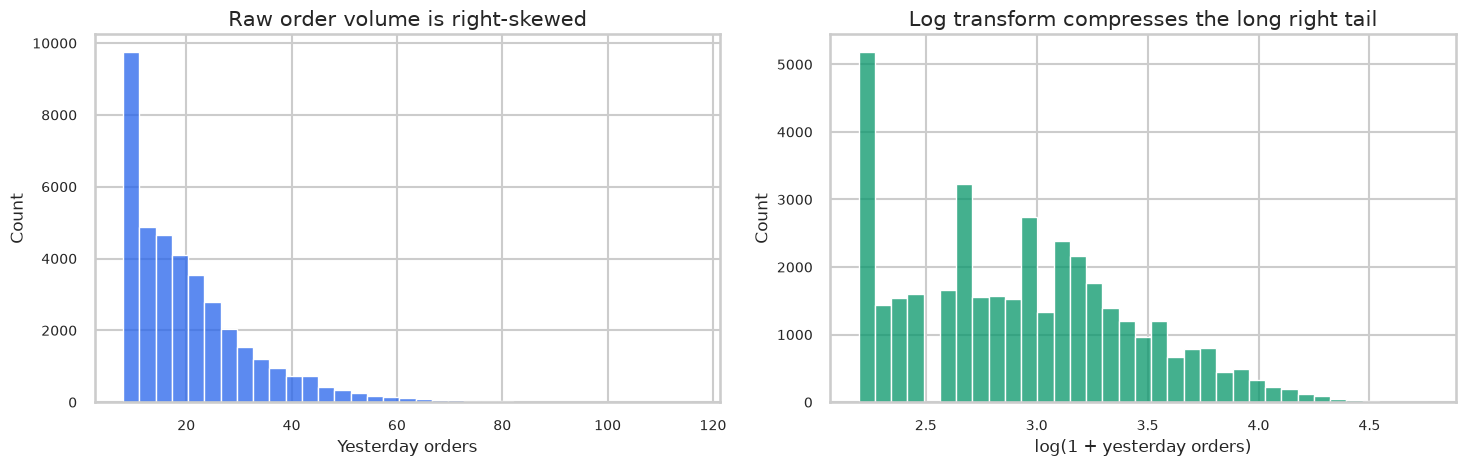

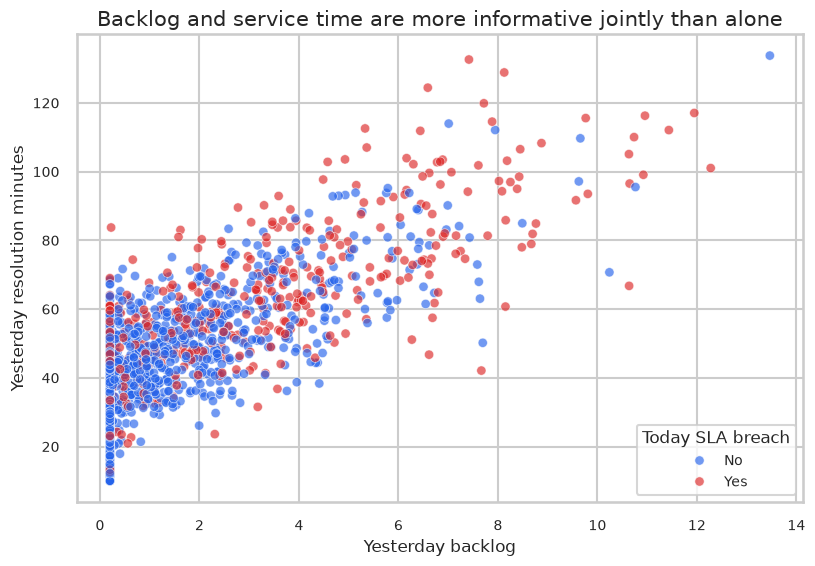

In [5]:
# Section focus: Feature families we will create.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(feature_df['orders_today_lag1'], bins=35, color='#2563eb', edgecolor='white', ax=axes[0])
axes[0].set_title('Raw order volume is right-skewed')
axes[0].set_xlabel('Yesterday orders')
axes[0].set_ylabel('Count')

sns.histplot(feature_df['log_orders_lag1'], bins=35, color='#059669', edgecolor='white', ax=axes[1])
axes[1].set_title('Log transform compresses the long right tail')
axes[1].set_xlabel('log(1 + yesterday orders)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

sample_plot = feature_df.sample(2500, random_state=2026).copy()
sample_plot['breach_label'] = sample_plot['sla_breach_today'].map({0: 'No', 1: 'Yes'})

plt.figure(figsize=(8.5, 6))
sns.scatterplot(
    data=sample_plot,
    x='backlog_end_today_lag1',
    y='resolution_minutes_today_lag1',
    hue='breach_label',
    hue_order=['No', 'Yes'],
    palette={'No': '#2563eb', 'Yes': '#dc2626'},
    alpha=0.65,
    s=45,
)
plt.title('Backlog and service time are more informative jointly than alone')
plt.xlabel('Yesterday backlog')
plt.ylabel('Yesterday resolution minutes')
legend = plt.legend(title='Today SLA breach', loc='lower right', frameon=True)
legend.get_title().set_fontsize(12)
for text in legend.get_texts():
    text.set_fontsize(10)
plt.tight_layout()
plt.show()

The transformation plot shows a classic reason to engineer numeric variables: raw business counts often have long right tails, and a simple log transform can create a representation that is easier for linear models to use. The scatterplot reinforces a second point: many operational relationships are not isolated. Queue pressure and realized service time often reinforce each other, which is one reason interaction-style features can be useful.

## 4. Model Comparison Under a Chronological Split

To evaluate feature engineering fairly, we split the panel chronologically:

- **training**: first 70 percent of days,
- **validation**: next 15 percent,
- **test**: final 15 percent.

This is more faithful to deployment than a random row-level split because it prevents future data from influencing earlier predictions. Lai et al. (2024) emphasize that temporal validation must respect forecasting chronology; otherwise, feature selection and model tuning can become optimistically biased.

We compare three logistic-regression pipelines:

1. **Raw lagged baseline**: static attributes plus simple one-day lagged levels,
2. **Engineered deployable features**: baseline plus transforms, rates, interactions, rolling summaries, and cyclical encodings,
3. **Engineered + leaky same-day features**: the deployable set plus same-day quantities that would not be known when the prediction is made.

The leaky model is included on purpose. It is a controlled failure mode.

In [6]:
# Section focus: 4. Model Comparison Under a Chronological Split.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

raw_features = [
    'tier', 'region', 'automation_score', 'complexity_score', 'day_of_week',
    'orders_today_lag1', 'tickets_today_lag1', 'promo_spend_today_lag1',
    'knowledge_base_views_today_lag1', 'incident_count_today_lag1',
    'agent_hours_today_lag1', 'backlog_end_today_lag1', 'resolution_minutes_today_lag1'
]

engineered_features = raw_features + [
    'log_orders_lag1', 'log_backlog_lag1', 'backlog_per_hour_lag1', 'ticket_rate_lag1',
    'self_service_gap_lag1', 'tickets_3d_avg', 'tickets_7d_avg', 'backlog_3d_avg',
    'backlog_7d_avg', 'breach_14d_rate', 'incident_7d_sum', 'backlog_growth_vs_7d',
    'promo_pressure_interaction', 'incident_pressure_interaction', 'dow_sin', 'dow_cos'
]

leaky_same_day_features = engineered_features + [
    'orders_today', 'tickets_today', 'backlog_end_today', 'resolution_minutes_today', 'incident_count_today'
]


def chronological_split(df):
    """Carry out the chronological split step used in the 14. Feature Engineering for Operational Machine Learning workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    dates = np.sort(df['date'].unique())
    train_end = dates[int(len(dates) * 0.70)]
    valid_end = dates[int(len(dates) * 0.85)]

    train = df[df['date'] <= train_end].copy()
    valid = df[(df['date'] > train_end) & (df['date'] <= valid_end)].copy()
    test = df[df['date'] > valid_end].copy()
    return train, valid, test


def make_pipeline(feature_cols):
    """Construct the pipeline helper used in the 14. Feature Engineering for Operational Machine Learning workflow.
    
    Parameters
    ----------
    feature_cols : object
        Column or variable name used to select information from the input table.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the pipeline workflow.
    """
    categorical = [col for col in feature_cols if col in ['tier', 'region']]
    numeric = [col for col in feature_cols if col not in categorical]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                'num',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                ]),
                numeric,
            ),
            (
                'cat',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore')),
                ]),
                categorical,
            ),
        ]
    )

    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1200, C=1.0)),
    ])


def fit_and_score_models(df, feature_sets):
    """Fit the and score models model or object used in the 14. Feature Engineering for Operational Machine Learning analysis.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    feature_sets : object
        Column or variable name used to select information from the input table.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    train, valid, test = chronological_split(df)
    fitted_models = {}
    rows = []

    for name, cols in feature_sets.items():
        pipe = make_pipeline(cols)
        pipe.fit(train[cols], train['sla_breach_today'])
        fitted_models[name] = pipe

        for split_name, split_df in [('validation', valid), ('test', test)]:
            probs = pipe.predict_proba(split_df[cols])[:, 1]
            rows.append({
                'model': name,
                'split': split_name,
                'auc': roc_auc_score(split_df['sla_breach_today'], probs),
                'average_precision': average_precision_score(split_df['sla_breach_today'], probs),
                'brier_score': brier_score_loss(split_df['sla_breach_today'], probs),
                'log_loss': log_loss(split_df['sla_breach_today'], probs),
            })

    return pd.DataFrame(rows), fitted_models, (train, valid, test)


feature_sets = {
    'Raw lagged baseline': raw_features,
    'Engineered deployable': engineered_features,
    'Engineered + same-day leakage': leaky_same_day_features,
}

metrics_long, fitted_models, splits = fit_and_score_models(feature_df, feature_sets)
metrics_long = metrics_long.round(3)
metrics_long

,model,split,auc,average_precision,brier_score,log_loss
0,Raw lagged baseline,validation,0.747,0.510,0.148,0.462
1,Raw lagged baseline,test,0.756,0.508,0.146,0.457
2,Engineered deployable,validation,0.750,0.510,0.148,0.461
3,Engineered deployable,test,0.758,0.516,0.145,0.455
4,Engineered + same-day leakage,validation,0.805,0.612,0.131,0.417
5,Engineered + same-day leakage,test,0.800,0.614,0.130,0.417


The comparison should be read with some discipline:

- The **raw lagged baseline** is already reasonable, because yesterday's queue state carries real signal.
- The **engineered deployable** model improves only modestly. That is not a failure. In real systems, careful feature engineering often produces incremental but meaningful gains rather than magic.
- The **same-day leakage** model jumps much more sharply. That extra performance is not trustworthy because the model has access to variables that are downstream of the day's unfolding operations.

This is one of the most important lessons in operational ML: a stronger validation score still needs a deployment-realism check.

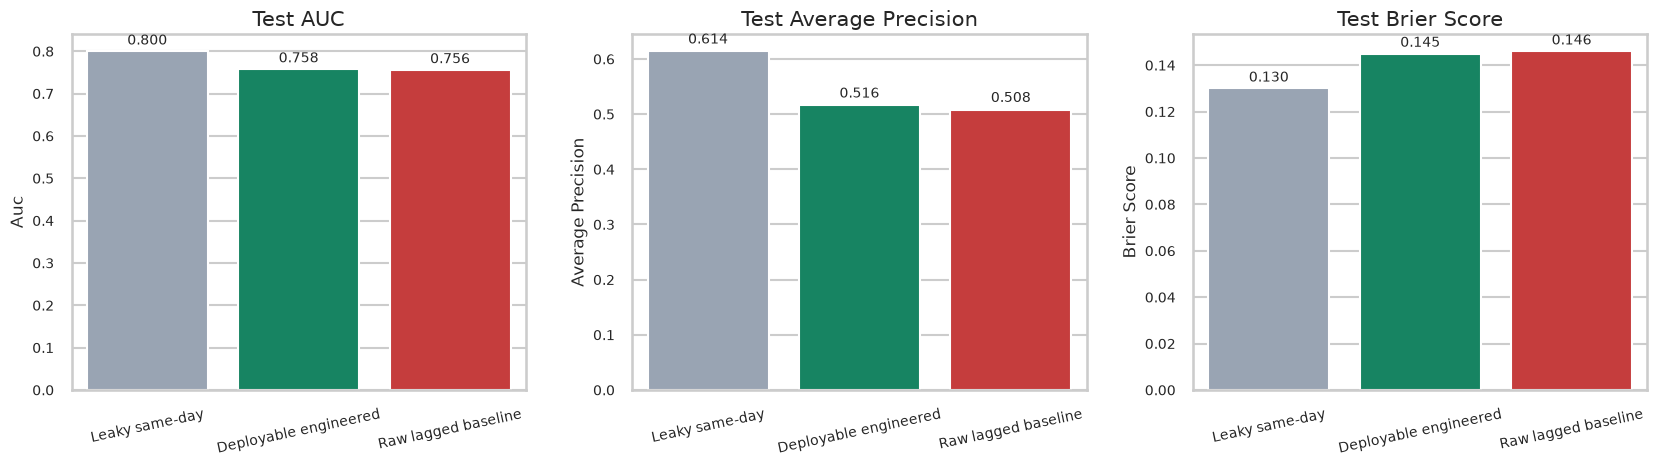

In [7]:
# Section focus: 4. Model Comparison Under a Chronological Split.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

test_metrics = metrics_long[metrics_long['split'] == 'test'].copy()
plot_name_map = {
    'Engineered + same-day leakage': 'Leaky same-day',
    'Engineered deployable': 'Deployable engineered',
    'Raw lagged baseline': 'Raw lagged baseline',
}
test_metrics['plot_model'] = test_metrics['model'].map(plot_name_map)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metric_specs = [
    ('auc', 'Test AUC', False),
    ('average_precision', 'Test Average Precision', False),
    ('brier_score', 'Test Brier Score', True),
]

palette = ['#94a3b8', '#059669', '#dc2626']

for ax, (metric, title, lower_is_better) in zip(axes, metric_specs):
    ordered = test_metrics.sort_values(metric, ascending=lower_is_better)
    sns.barplot(data=ordered, x='plot_model', y=metric, palette=palette, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=12, labelsize=10)

    for patch, value in zip(ax.patches, ordered[metric]):
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        ax.text(x, y + (0.008 if not lower_is_better else 0.0015), f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

The bar charts make the story easy to communicate to a nontechnical stakeholder:

- feature engineering created a small but honest improvement,
- leakage created a larger but invalid improvement.

That is exactly the tradeoff we want students to internalize. Engineering work should serve deployment realism instead of benchmark cosmetics.

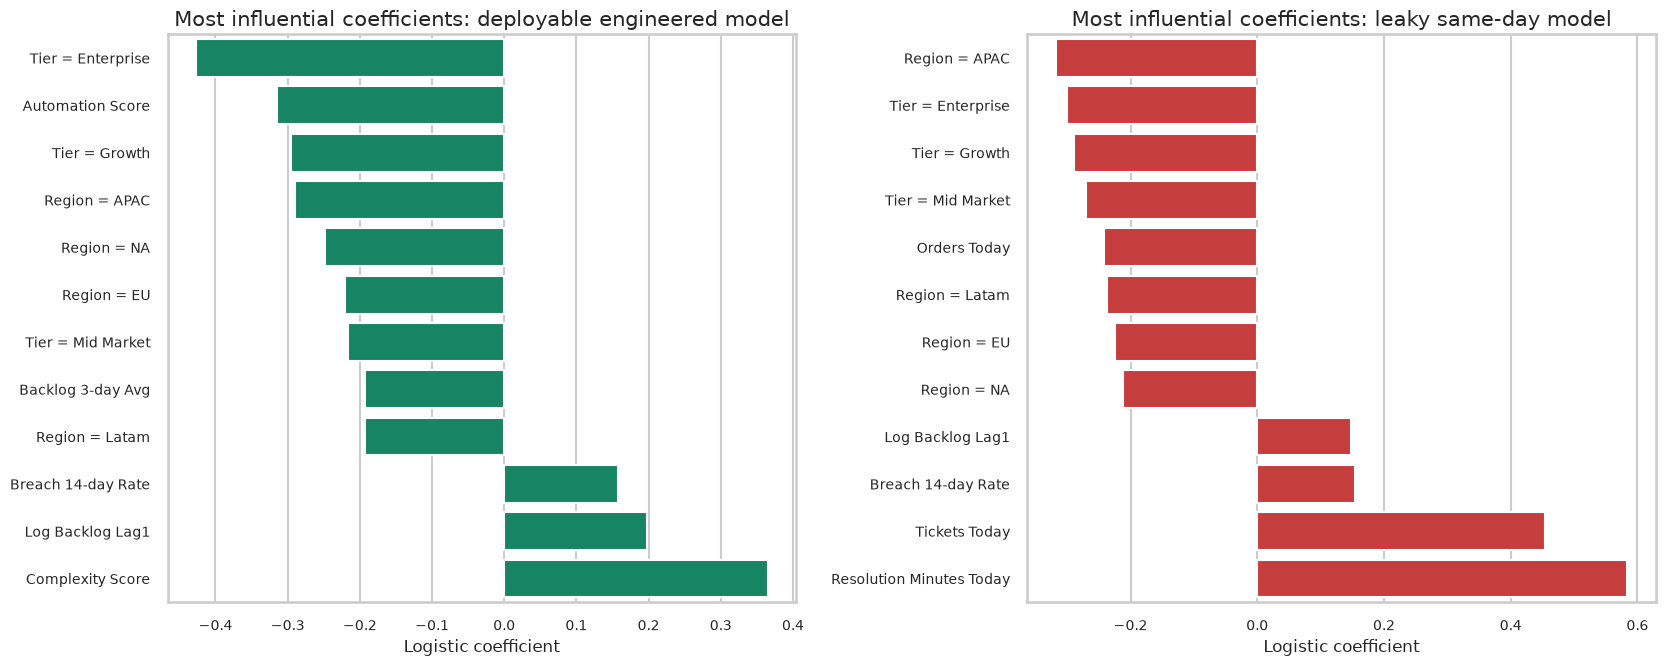

,feature,coefficient
27,Tier = Enterprise,-0.427
1,Complexity Score,0.365
0,Automation Score,-0.315
28,Tier = Growth,-0.296
31,Region = APAC,-0.289
34,Region = NA,-0.248
32,Region = EU,-0.221
30,Tier = Mid Market,-0.216
12,Log Backlog Lag1,0.197
18,Backlog 3-day Avg,-0.193


In [8]:
# Section focus: 4. Model Comparison Under a Chronological Split.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def extract_logistic_coefficients(pipeline):
    """Extract logistic coefficients for the 14. Feature Engineering for Operational Machine Learning workflow.
    
    Parameters
    ----------
    pipeline : object
        Scikit-learn pipeline that combines preprocessing and estimation.
    
    Returns
    -------
    object
        Intermediate result produced by the logistic coefficients calculation and reused by later cells.
    """
    feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    coefs = pipeline.named_steps['model'].coef_[0]
    out = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
    out['abs_coefficient'] = out['coefficient'].abs()
    out['feature'] = (
        out['feature']
        .str.replace('num__', '', regex=False)
        .str.replace('cat__', '', regex=False)
        .str.replace('onehot__', '', regex=False)
        .str.replace('tier_', 'Tier = ', regex=False)
        .str.replace('region_', 'Region = ', regex=False)
        .str.replace('_', ' ', regex=False)
        .str.title()
    )
    out['feature'] = out['feature'].replace({
        'Region = Apac': 'Region = APAC',
        'Region = Na': 'Region = NA',
        'Region = Eu': 'Region = EU',
        'Backlog 3D Avg': 'Backlog 3-day Avg',
        'Backlog 7D Avg': 'Backlog 7-day Avg',
        'Tickets 3D Avg': 'Tickets 3-day Avg',
        'Tickets 7D Avg': 'Tickets 7-day Avg',
        'Breach 14D Rate': 'Breach 14-day Rate',
        'Incident 7D Sum': 'Incident 7-day Sum',
    })
    return out.sort_values('abs_coefficient', ascending=False)


engineered_coef = extract_logistic_coefficients(fitted_models['Engineered deployable']).head(12)
leaky_coef = extract_logistic_coefficients(fitted_models['Engineered + same-day leakage']).head(12)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.barplot(data=engineered_coef.sort_values('coefficient'), x='coefficient', y='feature', color='#059669', ax=axes[0])
axes[0].set_title('Most influential coefficients: deployable engineered model')
axes[0].set_xlabel('Logistic coefficient')
axes[0].set_ylabel('')

sns.barplot(data=leaky_coef.sort_values('coefficient'), x='coefficient', y='feature', color='#dc2626', ax=axes[1])
axes[1].set_title('Most influential coefficients: leaky same-day model')
axes[1].set_xlabel('Logistic coefficient')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

engineered_coef[['feature', 'coefficient']].head(10)

The coefficient panels are useful for diagnosis.

In this simulation, some of the strongest effects still come from structural account differences such as tier, region, automation, and complexity. That is realistic: representation design does not erase the importance of baseline heterogeneity. What feature engineering does is add a second layer of signal. Engineered quantities such as backlog intensity, transformed backlog, rolling burden summaries, and normalized rates now enter the model alongside those baseline attributes.

That is a healthy pattern. The model is not pretending that one feature explains everything. Instead, it combines stable account context with carefully designed operational summaries.

The leaky model tells a different story. Same-day variables can dominate because they are downstream reflections of the event we are trying to predict. If a model suddenly becomes much stronger after adding features like same-day resolution minutes or same-day backlog, the right reaction is not celebration. The right reaction is an audit of the decision timestamp and the feature construction pipeline.

## 5. Practical Checklist for Feature Engineering in Decision Systems

When you engineer features for real operational models, a useful checklist is:

1. **Define the decision timestamp first.** Before writing any code, state exactly when the prediction is made.
2. **Write features as business hypotheses.** Each feature should answer a meaningful question such as "burden relative to capacity" or "recent stability trend."
3. **Prefer normalized quantities when scale varies widely.** Rates, shares, and per-unit burdens often generalize better than raw counts alone.
4. **Use rolling summaries to stabilize noisy logs.** But compute them only from past data.
5. **Respect chronology in both features and validation.** Random shuffling can make temporal features look better than they really are.
6. **Interrogate suspicious gains.** If performance jumps sharply after adding a feature, ask whether the feature is downstream, post-outcome, or timestamp-misaligned.
7. **Keep the baseline.** A raw baseline is not a nuisance; it is how we learn whether engineering work truly added value.

A final conceptual point is worth keeping in view. Feature engineering is not separate from modeling judgment. It *is* modeling judgment, expressed through representation design.

## References

- Christ, M., Braun, N., Neuffer, J., et al. (2018). *Time Series FeatuRe Extraction on basis of Scalable Hypothesis tests (tsfresh - A Python package).* Neurocomputing, 307, 72-77. [https://doi.org/10.1016/j.neucom.2018.03.067](https://doi.org/10.1016/j.neucom.2018.03.067)
- Kanter, J. M., & Veeramachaneni, K. (2015). *Deep feature synthesis: Towards automating data science endeavors.* 2015 IEEE International Conference on Data Science and Advanced Analytics, 1-10. [https://doi.org/10.1109/DSAA.2015.7344858](https://doi.org/10.1109/DSAA.2015.7344858)
- Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). *Leakage in data mining.* ACM Transactions on Knowledge Discovery from Data, 6(4), 1-21. [https://doi.org/10.1145/2382577.2382579](https://doi.org/10.1145/2382577.2382579)
- Lai, M., Wulff, S. S., Cao, Y., Robinson, T. J., & Rajapaksha, R. (2025). *Temporal cross-validation in forecasting: A case study of COVID-19 incidence using wastewater data.* Quality and Reliability Engineering International, 41(2), 672-688. [https://doi.org/10.1002/qre.3686](https://doi.org/10.1002/qre.3686)
